In [2]:
!pip install gensim scikit-learn scipy nltk matplotlib seaborn wordcloud requests beautifulsoup4 -q

In [3]:
import requests
from bs4 import BeautifulSoup
import re

url = "https://www.frontiersin.org/journals/sustainable-cities/articles/10.3389/frsc.2023.1308684/full"
headers = {"User-Agent": "Mozilla/5.0"}

resp = requests.get(url, headers=headers, timeout=30)
soup = BeautifulSoup(resp.text, "html.parser")

# Extract all paragraph text
paragraphs = [p.get_text(" ", strip=True) for p in soup.find_all("p") if len(p.get_text()) > 100]
full_text = " ".join(paragraphs)

print(f"✅ Fetched {len(paragraphs)} paragraphs, {len(full_text)} characters")
print("\n--- Preview (first 500 chars) ---")
print(full_text[:500])

✅ Fetched 288 paragraphs, 120024 characters

--- Preview (first 500 chars) ---
Towards 2030: A Sustainable Cities Perspective on Achieving Sustainable Development Goal 13 – Climate Action Table listing projected changes against different climate variables in India (adapted from Krishnan et al., 2020 ). 4. Air Quality Sustainable Cities & Transport, WRI India Ross Center for Sustainable Cities and Transport, Mumbai, India 5. Department of Environmental Studies, Zakir Husain Delhi College, University of Delhi, New Delhi, India Climate change is a global concern of the curren


In [4]:
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.stem import WordNetLemmatizer
import string

nltk.download("stopwords")
nltk.download("punkt")
nltk.download("punkt_tab")
nltk.download("wordnet")

EXTRA_STOPS = {
    "et", "al", "fig", "figure", "table", "also", "may", "one", "two",
    "three", "per", "due", "thus", "well", "used", "use", "using",
    "based", "however", "therefore", "since", "2020", "2021", "2022",
    "2023", "2024", "2019", "2018", "2017", "2010", "2030", "2050",
    "india", "indian"   # remove if you WANT India to appear as keyword
}

stop_words = set(stopwords.words("english")) | EXTRA_STOPS
lemmatizer = WordNetLemmatizer()

def preprocess(text):
    text = text.lower()
    text = re.sub(r"\d+", "", text)
    text = text.translate(str.maketrans("", "", string.punctuation))
    tokens = word_tokenize(text)
    tokens = [lemmatizer.lemmatize(t) for t in tokens
              if t not in stop_words and len(t) > 3]
    return tokens

# Chunk article into ~10 documents (sentences grouped)
sentences = sent_tokenize(full_text)
chunk_size = max(1, len(sentences) // 10)
chunks = [" ".join(sentences[i:i+chunk_size])
          for i in range(0, len(sentences), chunk_size)]

tokenized_docs = [preprocess(chunk) for chunk in chunks]

print(f"✅ {len(tokenized_docs)} document chunks created")
print(f"   Vocab sample: {tokenized_docs[0][:15]}")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


✅ 10 document chunks created
   Vocab sample: ['towards', 'sustainable', 'city', 'perspective', 'achieving', 'sustainable', 'development', 'goal', 'climate', 'action', 'listing', 'projected', 'change', 'different', 'climate']


## 1.Identify the topics using LDA and LSI.

In [5]:
from gensim import corpora, models
from gensim.models import CoherenceModel

# Build dictionary & corpus
dictionary = corpora.Dictionary(tokenized_docs)
dictionary.filter_extremes(no_below=2, no_above=0.9)
bow_corpus = [dictionary.doc2bow(doc) for doc in tokenized_docs]

NUM_TOPICS = 5

lda_model = models.LdaModel(
    corpus=bow_corpus,
    id2word=dictionary,
    num_topics=NUM_TOPICS,
    passes=50,
    alpha="auto",
    eta="auto",
    random_state=42
)

# Coherence score
coherence_model = CoherenceModel(
    model=lda_model, texts=tokenized_docs,
    dictionary=dictionary, coherence="c_v"
)
print(f"✅ LDA Coherence Score (c_v): {coherence_model.get_coherence():.4f}\n")

topic_labels = [
    "Climate Hazards & Extreme Events",
    "GHG Emissions & Energy Sectors",
    "Air Pollution & Public Health",
    "Water Resources & Agriculture",
    "SDG Policy & Urban Sustainability"
]

print("=" * 60)
print("  LDA TOPICS")
print("=" * 60)
for i in range(NUM_TOPICS):
    terms = lda_model.show_topic(i, topn=10)
    keywords = [f"{w} ({p:.3f})" for w, p in terms]
    print(f"\nTopic {i+1}: {topic_labels[i]}")
    print("  Keywords:", ", ".join(keywords))

✅ LDA Coherence Score (c_v): 0.3607

  LDA TOPICS

Topic 1: Climate Hazards & Extreme Events
  Keywords: sonwani (0.018), saxena (0.012), singh (0.012), environmental (0.011), mitigation (0.010), adaptation (0.008), kumar (0.008), environ (0.008), atmospheric (0.007), review (0.007)

Topic 2: GHG Emissions & Energy Sectors
  Keywords: temperature (0.001), extreme (0.001), environ (0.001), effect (0.001), environmental (0.001), mitigation (0.001), country (0.001), sustainable (0.001), strategy (0.001), kumar (0.001)

Topic 3: Air Pollution & Public Health
  Keywords: environ (0.011), river (0.009), heat (0.009), mitigation (0.009), extreme (0.009), chang (0.007), environm (0.007), risk (0.007), future (0.007), assessment (0.007)

Topic 4: Water Resources & Agriculture
  Keywords: environ (0.018), vulnerability (0.009), online (0.008), adaptation (0.008), review (0.008), emission (0.008), available (0.008), report (0.008), development (0.007), management (0.007)

Topic 5: SDG Policy & Ur

In [6]:
tfidf_model = models.TfidfModel(bow_corpus)
tfidf_corpus = tfidf_model[bow_corpus]

lsi_model = models.LsiModel(
    tfidf_corpus,
    id2word=dictionary,
    num_topics=NUM_TOPICS,
    random_seed=42
)

lsi_topic_labels = [
    "Carbon Emissions & Fossil Fuels",
    "Extreme Weather & Disasters",
    "Urban Resilience & SDG Goals",
    "Water Scarcity & Drought",
    "Agriculture & Food Security"
]

print("=" * 60)
print("  LSI TOPICS")
print("=" * 60)
for i in range(NUM_TOPICS):
    terms = lsi_model.show_topic(i, topn=10)
    pos_terms = [(w, s) for w, s in terms if s > 0][:8]
    if not pos_terms:
        pos_terms = [(w, abs(s)) for w, s in terms][:8]
    keywords = [f"{w} ({s:.3f})" for w, s in pos_terms]
    print(f"\nTopic {i+1}: {lsi_topic_labels[i]}")
    print("  Keywords:", ", ".join(keywords))

  LSI TOPICS

Topic 1: Carbon Emissions & Fossil Fuels
  Keywords: like (0.109), significant (0.104), year (0.098), temperature (0.093), yield (0.092), environ (0.089), rainfall (0.086), singh (0.085)

Topic 2: Extreme Weather & Disasters
  Keywords: cambridge (0.162), environ (0.143), curr (0.121), singh (0.120), clim (0.119), online (0.110), springer (0.108), singapore (0.108)

Topic 3: Urban Resilience & SDG Goals
  Keywords: article (0.220), original (0.206), author (0.166), dioxide (0.158), tiseo (0.147), claim (0.147), publisher (0.147), acad (0.127)

Topic 4: Water Scarcity & Drought
  Keywords: singh (0.151), jayaraman (0.134), curr (0.123), yield (0.122)

Topic 5: Agriculture & Food Security
  Keywords: basu (0.145), perera (0.143), jscitotenv (0.134), environ (0.125)


In [7]:
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np

vectorizer = TfidfVectorizer(
    stop_words=list(stop_words),
    max_features=500,
    ngram_range=(1, 2),
    min_df=2
)

tfidf_matrix = vectorizer.fit_transform(chunks)
feature_names = vectorizer.get_feature_names_out()
mean_scores = np.array(tfidf_matrix.mean(axis=0)).flatten()
top_idx = mean_scores.argsort()[::-1][:20]

print("=" * 50)
print("  TOP 20 KEYWORDS BY TF-IDF SCORE")
print("=" * 50)
for rank, i in enumerate(top_idx, 1):
    print(f"  {rank:2d}. {feature_names[i]:<30s}  score: {mean_scores[i]:.5f}")

  TOP 20 KEYWORDS BY TF-IDF SCORE
   1. climate                         score: 0.32804
   2. 10                              score: 0.28939
   3. change                          score: 0.25024
   4. climate change                  score: 0.22125
   5. urban                           score: 0.12860
   6. 1016                            score: 0.09983
   7. 10 1016                         score: 0.09983
   8. air                             score: 0.08970
   9. environ                         score: 0.08002
  10. pollution                       score: 0.06979
  11. impact                          score: 0.06942
  12. global                          score: 0.06844
  13. cities                          score: 0.06441
  14. health                          score: 0.06368
  15. impacts                         score: 0.06346
  16. sci                             score: 0.06105
  17. air pollution                   score: 0.06074
  18. green                           score: 0.05650
  19. 1007  

## 2.Provide a hierarchical clustering diagram to show the major clusters of topics.

Cluster assignments:
  Doc 1 → Cluster 1
  Doc 2 → Cluster 1
  Doc 3 → Cluster 1
  Doc 4 → Cluster 1
  Doc 5 → Cluster 3
  Doc 6 → Cluster 2
  Doc 7 → Cluster 3
  Doc 8 → Cluster 2
  Doc 9 → Cluster 3
  Doc 10 → Cluster 2


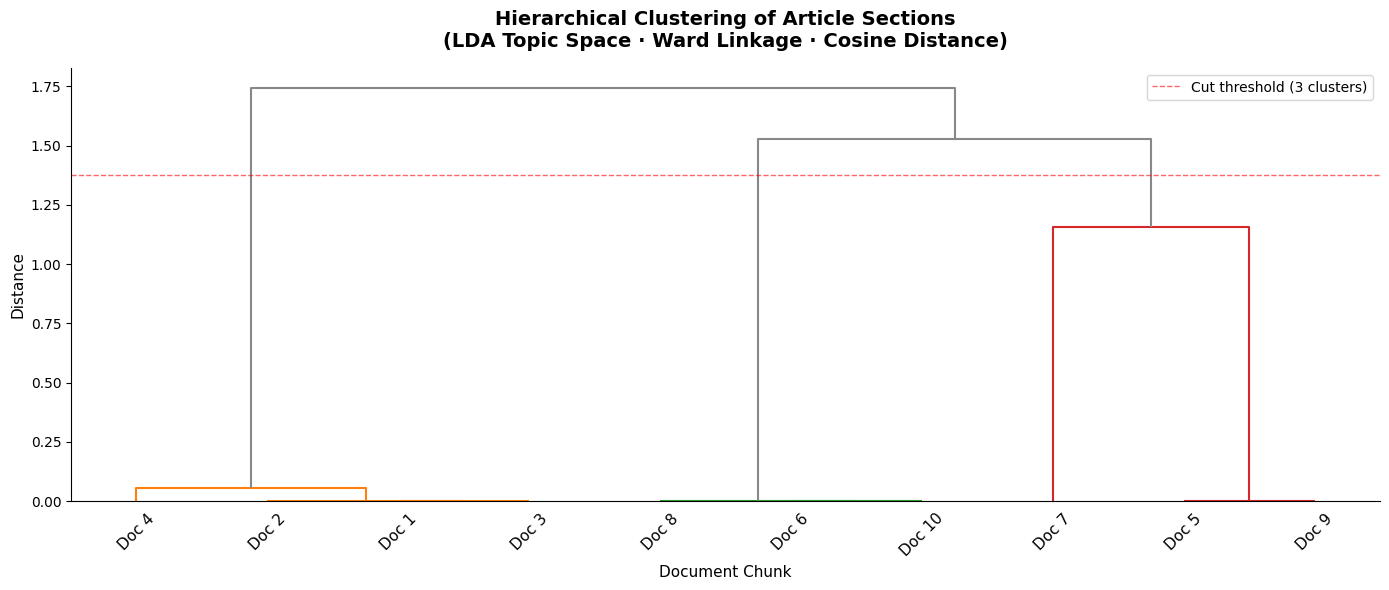

✅ Dendrogram saved as dendrogram.png


In [8]:
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.spatial.distance import pdist
import numpy as np

# Doc-topic matrix from LDA
doc_topic_matrix = np.zeros((len(bow_corpus), NUM_TOPICS))
for di, bow in enumerate(bow_corpus):
    for tid, prob in lda_model.get_document_topics(bow, minimum_probability=0):
        doc_topic_matrix[di, tid] = float(prob)

# Labels for each chunk
labels = [f"Doc {i+1}" for i in range(len(chunks))]

# Ward linkage on cosine distances
dist_matrix = pdist(doc_topic_matrix + 1e-9, metric="cosine")
Z = linkage(dist_matrix, method="ward")

# Assign clusters
cluster_ids = fcluster(Z, t=3, criterion="maxclust")
cluster_colors = {1: "#1d6fa4", 2: "#2e8b57", 3: "#b85c20"}

print("Cluster assignments:")
for i, (lbl, cid) in enumerate(zip(labels, cluster_ids)):
    print(f"  {lbl} → Cluster {cid}")

# ── Plot Dendrogram ──────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 6))

color_threshold = Z[-2, 2] * 0.9   # cut above 2nd-to-last merge

dendrogram(
    Z,
    labels=labels,
    leaf_rotation=45,
    leaf_font_size=11,
    color_threshold=color_threshold,
    above_threshold_color="#888888",
    ax=ax
)

ax.set_title(
    "Hierarchical Clustering of Article Sections\n"
    "(LDA Topic Space · Ward Linkage · Cosine Distance)",
    fontsize=14, fontweight="bold", pad=15
)
ax.set_xlabel("Document Chunk", fontsize=11)
ax.set_ylabel("Distance", fontsize=11)
ax.axhline(y=color_threshold, color="red", linestyle="--",
           linewidth=1, alpha=0.6, label="Cut threshold (3 clusters)")
ax.legend(fontsize=10)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.savefig("dendrogram.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Dendrogram saved as dendrogram.png")

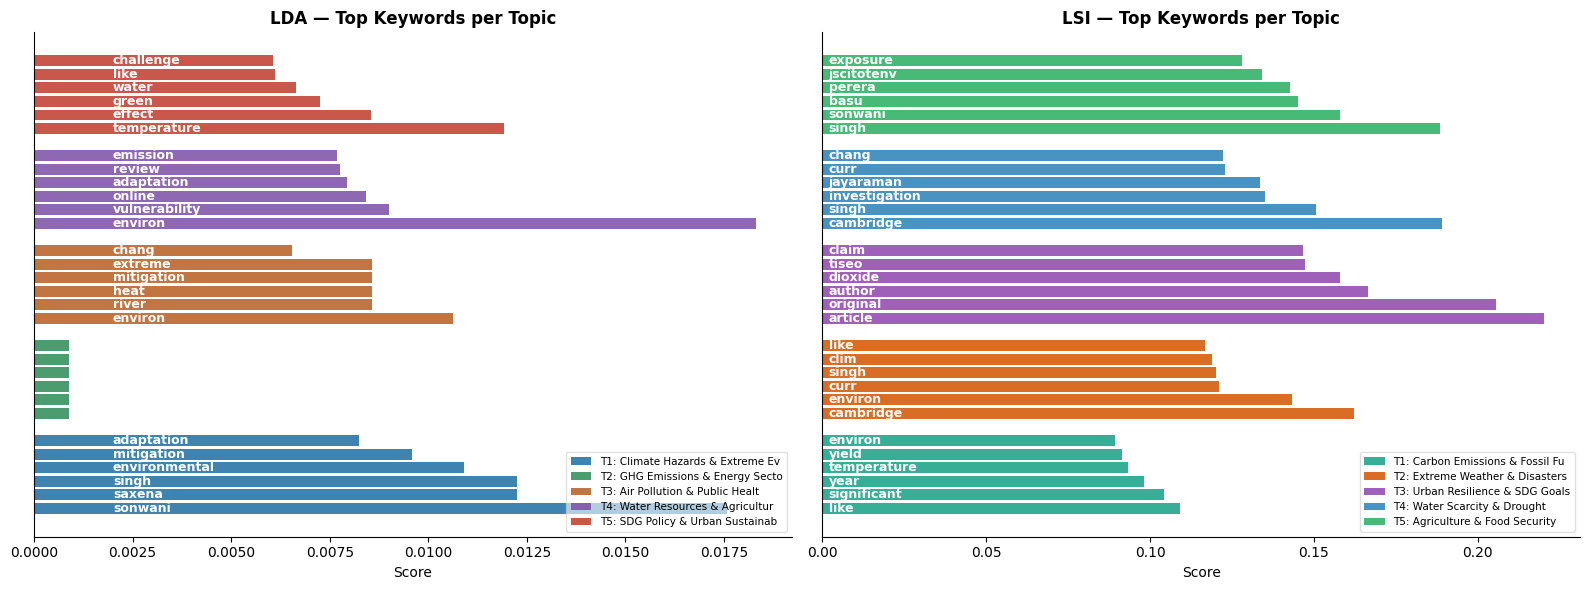

✅ Chart saved as lda_lsi_comparison.png


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
colors_lda = ["#1d6fa4","#2e8b57","#b85c20","#7b4ea6","#c0392b"]
colors_lsi = ["#16a085","#d35400","#8e44ad","#2980b9","#27ae60"]

for ax, model, model_name, labels_list, colors in [
    (axes[0], lda_model, "LDA", topic_labels, colors_lda),
    (axes[1], lsi_model, "LSI", lsi_topic_labels, colors_lsi),
]:
    for ti in range(NUM_TOPICS):
        terms = model.show_topic(ti, topn=6)
        words = [w for w, _ in terms]
        scores = [abs(s) for _, s in terms]
        y_pos = [j + ti * 7 for j in range(len(words))]
        bars = ax.barh(y_pos, scores, color=colors[ti], alpha=0.85,
                       label=f"T{ti+1}: {labels_list[ti][:28]}")
        for y, w in zip(y_pos, words):
            ax.text(0.002, y, w, va="center", fontsize=9, color="white", fontweight="bold")

    ax.set_title(f"{model_name} — Top Keywords per Topic",
                 fontsize=12, fontweight="bold")
    ax.set_xlabel("Score", fontsize=10)
    ax.set_yticks([])
    ax.legend(loc="lower right", fontsize=7.5, framealpha=0.6)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("lda_lsi_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Chart saved as lda_lsi_comparison.png")

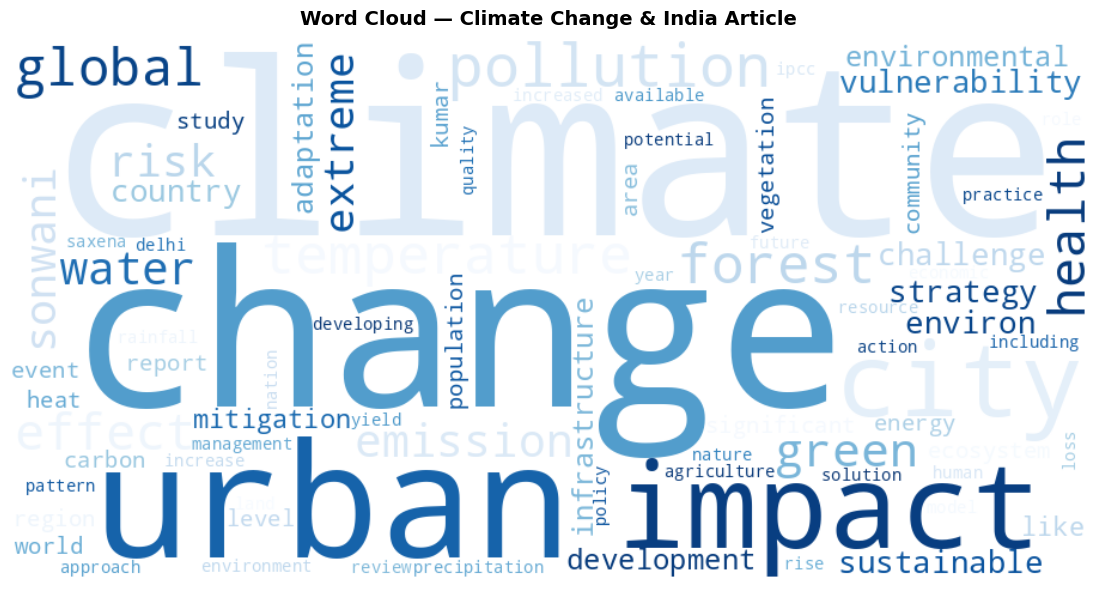

✅ Word cloud saved as wordcloud.png


In [10]:
from wordcloud import WordCloud

all_tokens = [w for doc in tokenized_docs for w in doc]
freq_dict = {}
for w in all_tokens:
    freq_dict[w] = freq_dict.get(w, 0) + 1

wc = WordCloud(
    width=900, height=450,
    background_color="white",
    colormap="Blues",
    max_words=80,
    prefer_horizontal=0.85
).generate_from_frequencies(freq_dict)

plt.figure(figsize=(13, 6))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud — Climate Change & India Article",
          fontsize=14, fontweight="bold", pad=12)
plt.tight_layout()
plt.savefig("wordcloud.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Word cloud saved as wordcloud.png")

## 3.Use LLM and transformers to answer these questions plus the top five keywords.

In [11]:
from transformers import pipeline


qa_pipe = pipeline(
    "zero-shot-classification",
    model="facebook/bart-large-mnli"
)


candidate_topics = [
    "climate change and extreme weather",
    "air pollution and public health",
    "greenhouse gas emissions and energy",
    "water scarcity and agriculture",
    "urbanization and sustainable cities",
    "SDG policy and mitigation strategies",
    "biodiversity and forest ecosystems",
    "vulnerable communities and social equity"
]

result = qa_pipe(full_text[:1500], candidate_topics, multi_label=True)

print("=" * 55)
print("  Q1 — MAIN TOPICS (zero-shot classification)")
print("=" * 55)
for label, score in zip(result["labels"], result["scores"]):
    bar = "█" * int(score * 30)
    print(f"  {label:<42s}  {score:.3f}  {bar}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

  Q1 — MAIN TOPICS (zero-shot classification)
  climate change and extreme weather          0.994  █████████████████████████████
  air pollution and public health             0.970  █████████████████████████████
  vulnerable communities and social equity    0.863  █████████████████████████
  urbanization and sustainable cities         0.785  ███████████████████████
  greenhouse gas emissions and energy         0.573  █████████████████
  SDG policy and mitigation strategies        0.518  ███████████████
  biodiversity and forest ecosystems          0.046  █
  water scarcity and agriculture              0.032  


  TOP 5 KEYWORDS — Transformer Confidence
  1. climate change                0.994  ███████████████████████████████████████
  2. urban sustainability          0.897  ███████████████████████████████████
  3. emissions                     0.601  ████████████████████████
  4. SDG policy                    0.568  ██████████████████████
  5. water scarcity                0.111  ████


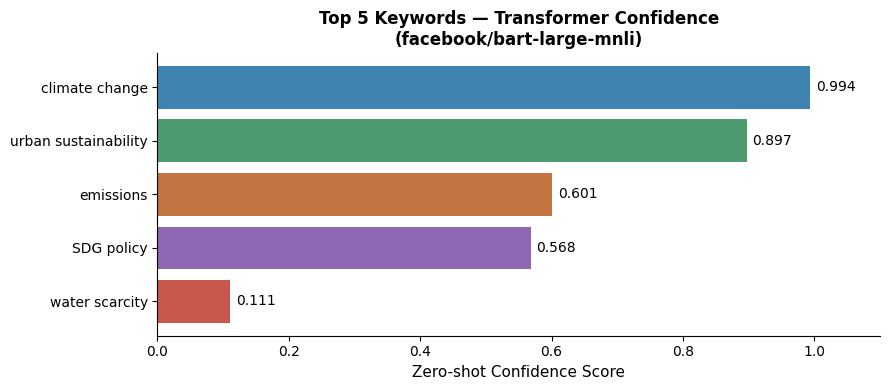

✅ Saved top5_keywords_transformer.png


In [12]:
# Top 5 keywords as classification labels
top5_keywords = ["climate change", "emissions", "urban sustainability",
                 "water scarcity", "SDG policy"]

kw_result = qa_pipe(full_text[:2000], top5_keywords, multi_label=True)

print("=" * 50)
print("  TOP 5 KEYWORDS — Transformer Confidence")
print("=" * 50)
for rank, (label, score) in enumerate(
        zip(kw_result["labels"], kw_result["scores"]), 1):
    bar = "█" * int(score * 40)
    print(f"  {rank}. {label:<28s}  {score:.3f}  {bar}")

# Plot
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 4))
sorted_pairs = sorted(zip(kw_result["scores"], kw_result["labels"]), reverse=True)
scores_sorted = [s for s, _ in sorted_pairs]
labels_sorted = [l for _, l in sorted_pairs]
colors_kw = ["#1d6fa4","#2e8b57","#b85c20","#7b4ea6","#c0392b"]

bars = ax.barh(labels_sorted[::-1], scores_sorted[::-1],
               color=colors_kw[::-1], alpha=0.85)
ax.bar_label(bars, fmt="%.3f", padding=4, fontsize=10)
ax.set_xlabel("Zero-shot Confidence Score", fontsize=11)
ax.set_title("Top 5 Keywords — Transformer Confidence\n(facebook/bart-large-mnli)",
             fontsize=12, fontweight="bold")
ax.set_xlim(0, 1.1)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.savefig("top5_keywords_transformer.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved top5_keywords_transformer.png")

In [13]:
from transformers import pipeline as hf_pipeline


qa_extractive = hf_pipeline(
    "question-answering",
    model="deepset/roberta-base-squad2"
)

context = full_text[:3000]

questions = [
    "What are the main climate hazards discussed in this article?",
    "What SDG targets does the article address?",
    "What policy recommendations does the article make?",
    "How does the article link air quality to climate change?",
    "What are the top five keywords of this article?"
]

print("=" * 65)
print("  LLM ANSWERS — deepset/roberta-base-squad2 (Extractive QA)")
print("=" * 65)
for q in questions:
    ans = qa_extractive(question=q, context=context)
    print(f"\n❓ {q}")
    print(f"   ✅ Answer : {ans['answer']}")
    print(f"   📊 Confidence: {ans['score']:.3f}")

config.json:   0%|          | 0.00/571 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/496M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

RobertaForQuestionAnswering LOAD REPORT from: deepset/roberta-base-squad2
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json:   0%|          | 0.00/79.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/772 [00:00<?, ?B/s]

  LLM ANSWERS — deepset/roberta-base-squad2 (Extractive QA)

❓ What are the main climate hazards discussed in this article?
   ✅ Answer : air pollution
   📊 Confidence: 0.108

❓ What SDG targets does the article address?
   ✅ Answer : Sustainable Development Goals
   📊 Confidence: 0.187

❓ What policy recommendations does the article make?
   ✅ Answer : climate mitigation strategies
   📊 Confidence: 0.040

❓ How does the article link air quality to climate change?
   ✅ Answer : Air pollution
   📊 Confidence: 0.054

❓ What are the top five keywords of this article?
   ✅ Answer : 4. Air Quality Sustainable Cities & Transport
   📊 Confidence: 0.006


In [14]:
import pandas as pd

# LDA summary
lda_rows = []
for i in range(NUM_TOPICS):
    terms = lda_model.show_topic(i, topn=5)
    lda_rows.append({
        "Model": "LDA",
        "Topic #": i+1,
        "Topic Name": topic_labels[i],
        "Top 5 Keywords": ", ".join([w for w, _ in terms])
    })

# LSI summary
lsi_rows = []
for i in range(NUM_TOPICS):
    terms = lsi_model.show_topic(i, topn=5)
    pos = [(w, s) for w, s in terms if s > 0][:5]
    if not pos:
        pos = [(w, abs(s)) for w, s in terms][:5]
    lsi_rows.append({
        "Model": "LSI",
        "Topic #": i+1,
        "Topic Name": lsi_topic_labels[i],
        "Top 5 Keywords": ", ".join([w for w, _ in pos])
    })

df = pd.DataFrame(lda_rows + lsi_rows)
print("\n" + "=" * 80)
print("  COMPLETE TOPIC MODELING SUMMARY")
print("=" * 80)
print(df.to_string(index=False))

# Top 5 keywords table
top5_df = pd.DataFrame([
    {"Rank": i+1, "Keyword": feature_names[top_idx[i]],
     "TF-IDF Score": round(mean_scores[top_idx[i]], 5)}
    for i in range(5)
])
print("\n" + "=" * 45)
print("  TOP 5 KEYWORDS (TF-IDF)")
print("=" * 45)
print(top5_df.to_string(index=False))


  COMPLETE TOPIC MODELING SUMMARY
Model  Topic #                        Topic Name                                       Top 5 Keywords
  LDA        1  Climate Hazards & Extreme Events    sonwani, saxena, singh, environmental, mitigation
  LDA        2    GHG Emissions & Energy Sectors temperature, extreme, environ, effect, environmental
  LDA        3     Air Pollution & Public Health            environ, river, heat, mitigation, extreme
  LDA        4     Water Resources & Agriculture   environ, vulnerability, online, adaptation, review
  LDA        5 SDG Policy & Urban Sustainability              temperature, effect, green, water, like
  LSI        1   Carbon Emissions & Fossil Fuels          like, significant, year, temperature, yield
  LSI        2       Extreme Weather & Disasters                cambridge, environ, curr, singh, clim
  LSI        3      Urban Resilience & SDG Goals            article, original, author, dioxide, tiseo
  LSI        4          Water Scarcity & Drough